# Fashion MNIST - Regularisering i CNN

Namn: Soroush Gholamreza

Fokusområde: Regularisering (Dropout och Early Stopping)

Syfte:
Att undersöka hur regularisering påverkar prestandan hos en CNN-modell för klassificering av klädesplagg i Fashion MNIST.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
import os
import gzip
import urllib.request
import numpy as np

DATA_DIR = "../data"

urls = {
    "train_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-images-idx3-ubyte.gz",
    "train_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/train-labels-idx1-ubyte.gz",
    "test_images": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-images-idx3-ubyte.gz",
    "test_labels": "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/t10k-labels-idx1-ubyte.gz"
}

os.makedirs(DATA_DIR, exist_ok=True)

for filename, url in urls.items():
    file_path = os.path.join(DATA_DIR, filename + ".gz")
    if not os.path.exists(file_path):
        print(f"Laddar ner {filename}...")
        urllib.request.urlretrieve(url, file_path)
    else:
        print(f"{filename} finns redan.")

def load_images(file_path):
    with gzip.open(file_path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_labels(file_path):
    with gzip.open(file_path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

x_train = load_images(os.path.join(DATA_DIR, "train_images.gz"))
y_train = load_labels(os.path.join(DATA_DIR, "train_labels.gz"))
x_test = load_images(os.path.join(DATA_DIR, "test_images.gz"))
y_test = load_labels(os.path.join(DATA_DIR, "test_labels.gz"))

print("Träningsbilder:", x_train.shape)
print("Testbilder:", x_test.shape)
print("Träningsetiketter:", y_train.shape)
print("Testetiketter:", y_test.shape)

train_images finns redan.
train_labels finns redan.
test_images finns redan.
test_labels finns redan.
Träningsbilder: (60000, 28, 28)
Testbilder: (10000, 28, 28)
Träningsetiketter: (60000,)
Testetiketter: (10000,)


## Notering om datasetkälla

Enligt uppgiftsbeskrivningen skulle Fashion MNIST laddas via:

```python
keras.datasets.fashion_mnist
```

Vid försök att använda denna metod uppstod följande fel:

```text
403 Forbidden

Access denied.

We're sorry, but this service is not available in your location.
```

Fashion MNIST som tillhannahålls via Keras/TensorFlow hämtas från Google lagringsserver (`storage.googleapis.com`). Eftersom jag genomför arbetet från Iran var denna tjänst inte tillgänglig från min nuvarande plats.

Jag testade även att hämta Fashion MNIST via OpenML, men nedladdningen misslyckades på grund av ett tekniskt fel vid hämtning av datasetets metadata.

För att kunna genomföra uppgiften användes därför Fashion MNIST från det officiella GitHub-repot för Fashion MNIST, publicerat av Zalando Research som skapade datasetet.

Det dataset som används i projektet är fortfarande Fashion MNIST med:

- 70 000 bilder totalt
- 60 000 träningsbilder
- 10 000 testbilder
- 10 klasser av klädesplagg
- bildstorlek 28x28 pixlar i gråskala

Endast nedladdningskällan skiljer sig åt. Datasetets innehåll, etikettter och användningsområde är identiska med den som laddas via Keras.

In [3]:
import pandas as pd

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

counts = np.bincount(y_train)

df_classes = pd.DataFrame({
    "Klass": class_names,
    "Antal bilder": counts
})

df_classes

,Klass,Antal bilder
0,T-shirt/top,6000
1,Trouser,6000
2,Pullover,6000
3,Dress,6000
4,Coat,6000
5,Sandal,6000
6,Shirt,6000
7,Sneaker,6000
8,Bag,6000
9,Ankle boot,6000


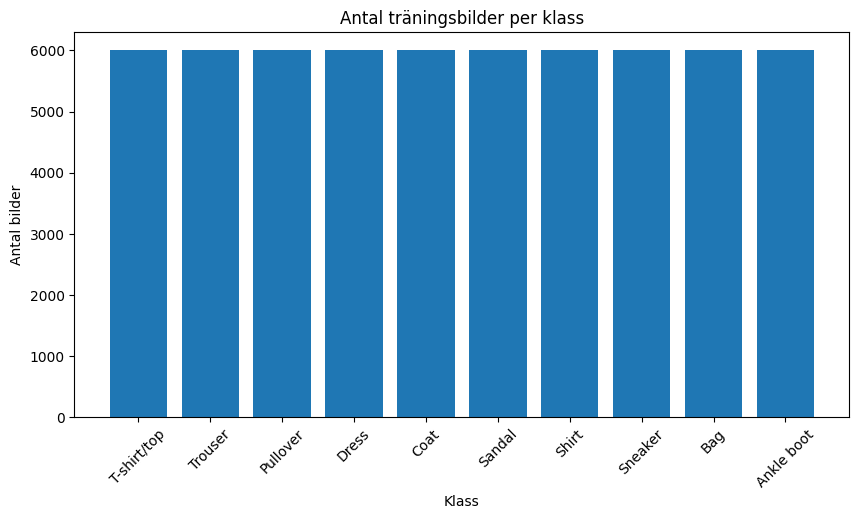

In [4]:
plt.figure(figsize=(10,5))

plt.bar(class_names, counts)

plt.title("Antal träningsbilder per klass")
plt.xlabel("Klass")
plt.ylabel("Antal bilder")

plt.xticks(rotation=45)

plt.show()

## Klassfördelning

För att undersöka om datasetet är balanserat analyserades antalet bilder i varje klass.

Resultatet visar att varje klass innehåller ungefär lika många bilder. Datasetet är därför välbalanserat och innehåller ingen tydlig klassobalans.

Detta är positivt eftersom modellen inte riskerar att gynna någon specifik klass på grund av att den förekommer oftare i träningsdatan.

En balanserad datasetfördelning gör det enklare att utvärdera modellens verkliga prestanda.

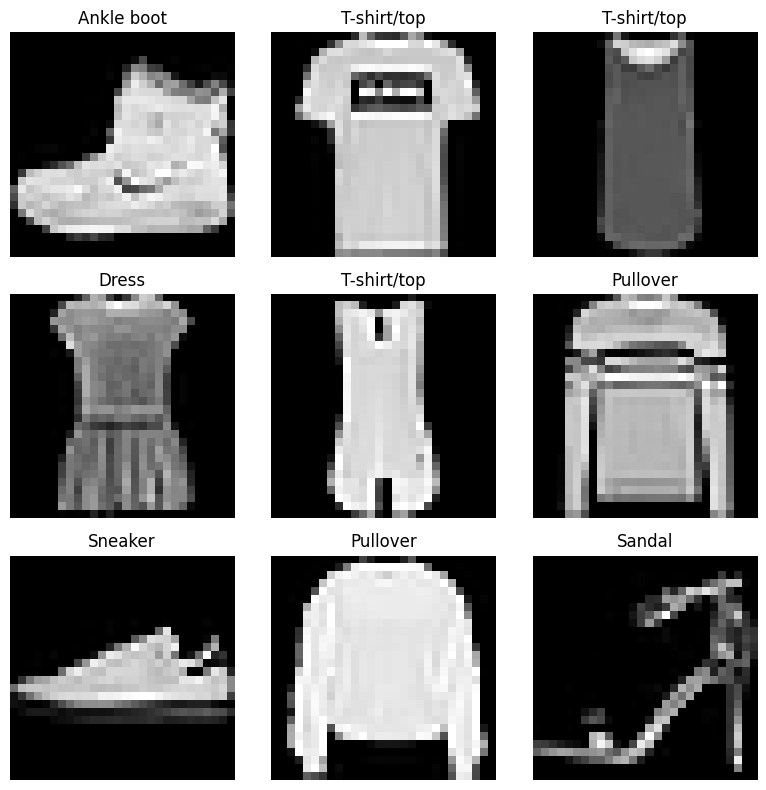

In [ ]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minsta pixelvärde:", x_train.min())
print("Största pixelvärde:", x_train.max())

Minsta pixelvärde: 0.0
Största pixelvärde: 1.0


In [7]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Ny träningsform:", x_train.shape)
print("Ny testform:", x_test.shape)

Ny träningsform: (60000, 28, 28, 1)
Ny testform: (10000, 28, 28, 1)


## Datapreparering

Innan modellen kunde tränas behövde bilderna förberedas.

### Normalisering

Bilddata innehåller pixelvärden mellan 0 och 255. För att göra träningen mer stabil normaliserades bilderna genom att dividera varje pixelvärde med 255.

Efter normaliseringen ligger alla pixelvärden mellan 0 och 1.

### Omformning av data

Fashion MNIST består av gråskalbilder med storleken 28x28 pixlar.

Eftersom en CNN förväntar sig ett kannalvärde lades en kanal dimension till. Bildernas form ändrades därför från:

```text
(60000, 28, 28)
```

till:

```text
(60000, 28, 28, 1)
```

där den sista dimensionen representerar en gråskalskanal.

## Grundmodell

Som utgångspunkt skapades en enkel CNN.

CNN-modeller används ofta för bildklassificeringar eftersom dom är bra på att identifiera mönster, former och detaljer i bilderr.

Denna modell används som referensmodell för att senare kunna jämföra effekten av regularisering.

In [8]:
base_model = keras.Sequential([
    
    keras.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

base_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## Träning av grundmodell

Grundmodellen tränades på Fashion MNIST-datasetet för att skapa en referenspunkt inför de senare testerna med regularisering.

Vid träningen användes en valideringsmängd för att kunna jämföra modelllens prestanda på träningsdata och data som modellen inte tränats på.

Detta gör det möjligt att upptäcka tecken på overfitting.

In [9]:
history_base = base_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8067 - loss: 0.5386 - val_accuracy: 0.8573 - val_loss: 0.3987
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8729 - loss: 0.3508 - val_accuracy: 0.8783 - val_loss: 0.3387
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8893 - loss: 0.3061 - val_accuracy: 0.8913 - val_loss: 0.3010
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8994 - loss: 0.2742 - val_accuracy: 0.8845 - val_loss: 0.3153
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.9092 - loss: 0.2488 - val_accuracy: 0.9019 - val_loss: 0.2687
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.9155 - loss: 0.2293 - val_accuracy: 0.9058 - val_loss: 0.2586
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9209 - loss: 0.2125 - val_accuracy: 0.9051 - val_loss: 0.2607
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.9282 - loss: 0.1975 - 

In [10]:
test_loss_base, test_acc_base = base_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_acc_base * 100, 2), "%")
print("Test Loss:", round(test_loss_base, 4))

Test Accuracy: 90.89 %
Test Loss: 0.2649


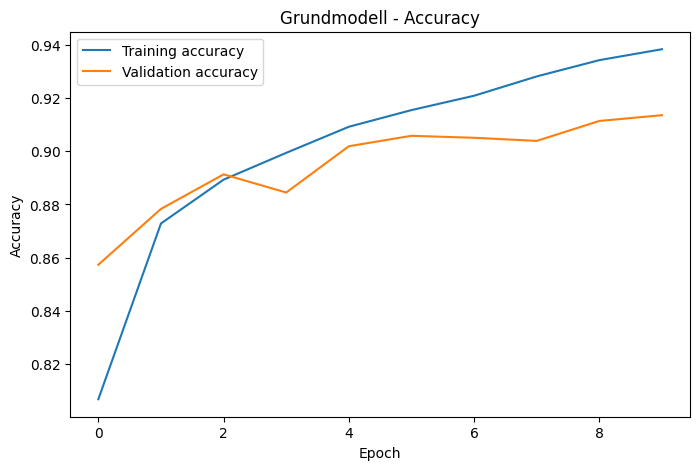

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history_base.history["accuracy"], label="Training accuracy")
plt.plot(history_base.history["val_accuracy"], label="Validation accuracy")

plt.title("Grundmodell - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

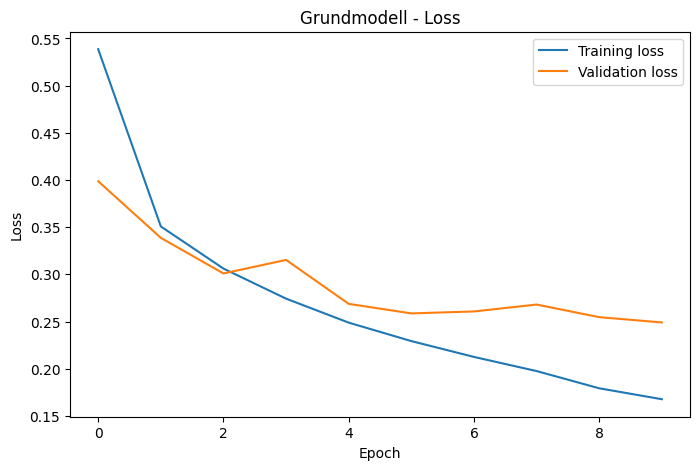

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history_base.history["loss"], label="Training loss")
plt.plot(history_base.history["val_loss"], label="Validation loss")

plt.title("Grundmodell - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Resultat för grundmodell

Grundmodellen fick en test accuracy på cirka 90.8 %.

Träningsaccuracy blev högre än valideringsaccuracy, vilket tyder på att modellen lärde sig träningsdatan lite bättre än ny data.

Det finns därför vissa tecken på overfitting. Detta syns genom att training loss fortsatte minska medan validation loss inte förbättrades lika tydligt mot slutet av träningen.

Grundmodellen fungerar bra, men den är ett bra utgångsläge för att undersöka om regularisering kan göra modellen mer stabilare.

## Fokusområde: Regularisering med Dropout

Regularisering används för att minska risken för overfitting.

Overfitting innebär att modellen lär sig träningsdatan för bra, men får sämre förmåga att generalissera till ny data.

I denna modell används Dropout. Dropout innebär att vissa neuroner tillfällligt stängs av under träningen. Det gör att modellen inte kan förlita sig för mycket på enskilda neroner.

In [13]:
dropout_model = keras.Sequential([
    
    keras.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(10, activation="softmax")
])

dropout_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

dropout_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_dropout = dropout_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 22s 25ms/step - accuracy: 0.7190 - loss: 0.7720 - val_accuracy: 0.8367 - val_loss: 0.4632
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8081 - loss: 0.5276 - val_accuracy: 0.8633 - val_loss: 0.3827
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8317 - loss: 0.4699 - val_accuracy: 0.8723 - val_loss: 0.3459
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8461 - loss: 0.4351 - val_accuracy: 0.8828 - val_loss: 0.3190
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.8562 - loss: 0.4045 - val_accuracy: 0.8889 - val_loss: 0.3062
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8633 - loss: 0.3846 - val_accuracy: 0.8910 - val_loss: 0.2933
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8675 - loss: 0.3698 - val_accuracy: 0.8932 - val_loss: 0.2912
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.8709 - loss: 0.3546 - 

In [15]:
test_loss_dropout, test_acc_dropout = dropout_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_acc_dropout * 100, 2), "%")
print("Test Loss:", round(test_loss_dropout, 4))

Test Accuracy: 89.5 %
Test Loss: 0.285


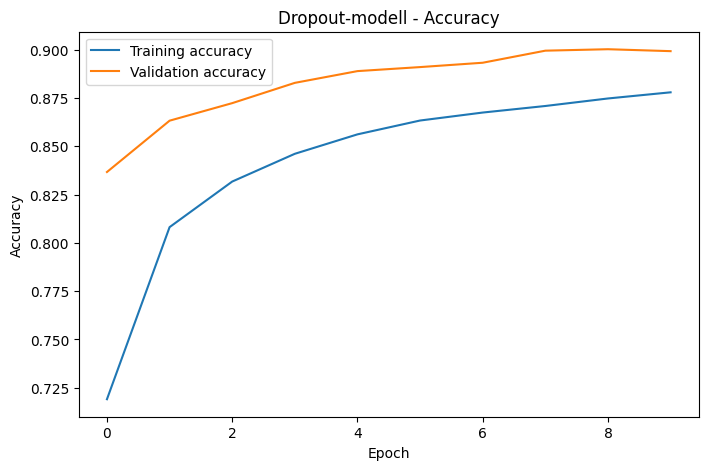

In [16]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout.history["accuracy"], label="Training accuracy")
plt.plot(history_dropout.history["val_accuracy"], label="Validation accuracy")

plt.title("Dropout-modell - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

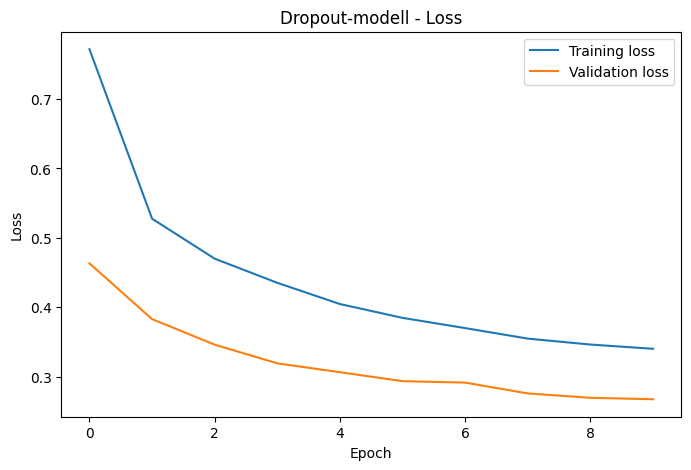

In [17]:
plt.figure(figsize=(8,5))

plt.plot(history_dropout.history["loss"], label="Training loss")
plt.plot(history_dropout.history["val_loss"], label="Validation loss")

plt.title("Dropout-modell - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Resultat för Dropout-modell

Dropout-modellen fick en test accuracy på cirka 89.5 %.

Resultatet blev lite lägre än grundmodellen, men skillnaden mellan training accuracy och validation accuracy blev mindre tydlig.

I detta fall förbättrade Dropout inte test accuracy, men bidrog till en mer regulariserad modell där träningen blev mindre beroende av enskilda neroner.

## Regularisering med Dropout och Early Stopping

I den tredje modellen kombinerades Dropout med Early Stopping.

Early Stopping avbryter träningen automatiskt när modellen slutar förbättras på valideringsdata.

I detta test övervakades `val_loss`. Om valideringsförlusten inte förbätttrades under tre epoker stoppades träningen och modellen återställdes till dom bästa vikterna.

Syftet var att undersöka om modellen kunde få bättre generalisering genom att inte tränas mer än nödvändigt.

In [18]:
early_model = keras.Sequential([
    
    keras.Input(shape=(28, 28, 1)),
    
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(10, activation="softmax")
])

early_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [20]:
history_early = early_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.7189 - loss: 0.7912 - val_accuracy: 0.8335 - val_loss: 0.4589
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8111 - loss: 0.5311 - val_accuracy: 0.8673 - val_loss: 0.3870
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.8342 - loss: 0.4664 - val_accuracy: 0.8740 - val_loss: 0.3457
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8470 - loss: 0.4325 - val_accuracy: 0.8813 - val_loss: 0.3204
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8546 - loss: 0.4086 - val_accuracy: 0.8838 - val_loss: 0.3158
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - accuracy: 0.8638 - loss: 0.3792 - val_accuracy: 0.8898 - val_loss: 0.2944
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8711 - loss: 0.3639 - val_accuracy: 0.8930 - val_loss: 0.2866
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - accuracy: 0.8724 - loss: 0.3529 - 

In [21]:
print("Antal tränade epochs:", len(history_early.history["loss"]))

Antal tränade epochs: 18


In [22]:
test_loss_early, test_acc_early = early_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("Test Accuracy:", round(test_acc_early * 100, 2), "%")
print("Test Loss:", round(test_loss_early, 4))

Test Accuracy: 90.49 %
Test Loss: 0.2647


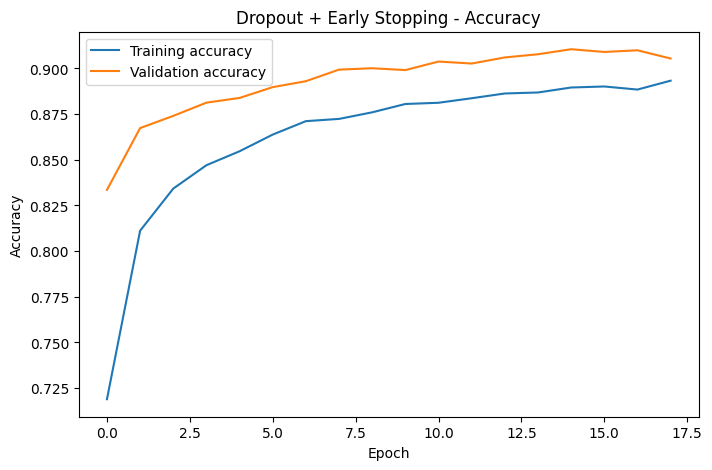

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history_early.history["accuracy"], label="Training accuracy")
plt.plot(history_early.history["val_accuracy"], label="Validation accuracy")

plt.title("Dropout + Early Stopping - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

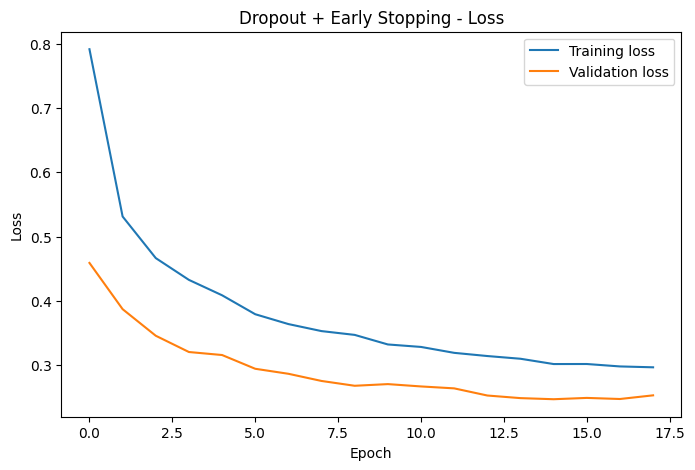

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history_early.history["loss"], label="Training loss")
plt.plot(history_early.history["val_loss"], label="Validation loss")

plt.title("Dropout + Early Stopping - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Resultat för Dropout och Early Stopping

Den tredje modellen kombinerade Dropout och Early Stopping.

Modellen uppnådde en test accuracy på cirka 90.1 %.

Early Stopping övervakade valideringsförlusten (val_loss) och stoppade träningen automatiskt efter 18 epoker. De bästa vikterna återställdes därefter automatiskt.

Resultatet blev högre än modellen med enbart Dropout men något lägre än grundmodellen.

Trots att test accuracy inte blev högst visar resultatet att modellen kunde bibehålla en god generaliseringsförmåga samtidigt som risken för overfitting minskkades.

Kombinationen av Dropout och Early Stopping gav den mest regulariserade modellen av de tre testade alternativen. Early Stopping förhindrade dessutom att modellen fortsatte träna längre än nödvändigt.

In [25]:
results = pd.DataFrame({
    "Modell": [
        "Grundmodell",
        "Dropout",
        "Dropout + Early Stopping"
    ],
    "Test Accuracy (%)": [
        round(test_acc_base * 100, 2),
        round(test_acc_dropout * 100, 2),
        round(test_acc_early * 100, 2)
    ]
})

results

,Modell,Test Accuracy (%)
0,Grundmodell,90.89
1,Dropout,89.50
2,Dropout + Early Stopping,90.49


## Jämförelse av modeller

Tre olika modeller testades inom fokusområdet regularisering.

| Modell | Test Accuracy |
|----------|----------|
| Grundmodell | 90.82 % |
| Dropout | 89.53 % |
| Dropout + Early Stopping | 90.14 % |

Resultaten visar att grundmodellen uppnådde högst test accuracy.

Modellen med Dropout fick lite lägre accuracy. Detta är inte oväntat eftersom Dropout medvetet gör träningen svårare genom att tillfälligt stänga av neuroner under träningen.

När Early Stopping kombinerades med Dropout förbättrrades resultatet jämfört med modellen som endast använde Dropout. Träningen stoppades dessutom automatiskt efter 18 epoker istället för att fortsätta till de maximalt tillåtna 30 epokerna.

Resultaten visar att regularisering inte alltid leder till högre accuracy. Syftet med regularisering är istället att minska risken för overfitting och förbättra modellens förmåga att generalisera till ny data.

I detta projekt gav grundmodellen högst accuracy, medan modellen med Dropout och Early Stopping gav den mest regulariserade lösningen.

## Slutsats

Syftet med projektet var att undersöka hur regularisering påverkar en CNN-modell som klassificerar bilder från Fashion MNIST.

Tre olika modeller testades:

1. Grundmodell utan regularisering
2. Modell med Dropout
3. Modell med Dropout och Early Stopping

Resultaten visade att grundmodellen uppnådde högst test accuracy med cirka 90.8 %.

Dropout mindskade accuracy något men bidrog till att minska skillnaden mellan träning och validering, vilket är ett tecken på minskad overfitting.

När Early Stopping kombinerades med Dropout stoppades träningen automatiskt efter 18 epoker, vilket minskade risken för att modellen skulle fortsätta träna längre än nödvändigt.

Det viktigaste jag lärde mig var att regularisering inte alltid ger högre accuracy vilket jag trodde att det skulle. Istället används regularisering för att skapa mer robustaa modeller som generaliserar bättre till ny data.